<a href="https://colab.research.google.com/github/meytriangg/Data-Mining-Course/blob/main/Student_Academic_Performance_Factors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Jumlah data dan kolom:
(6607, 20)

Contoh data:


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70



Evaluasi Model:
MAE : 1.767019667170953
MSE : 11.450832072617247
R2 Score : 0.18989930228905538

Faktor-faktor yang Berpengaruh terhadap Academic Performance:


,Faktor,Tingkat_Pengaruh
1,Attendance,0.385892
0,Hours_Studied,0.246859
6,Previous_Scores,0.095603
14,Physical_Activity,0.036941
9,Tutoring_Sessions,0.034580
3,Access_to_Resources,0.032107
2,Parental_Involvement,0.025041
5,Sleep_Hours,0.024298
13,Peer_Influence,0.019710
11,Teacher_Quality,0.017112


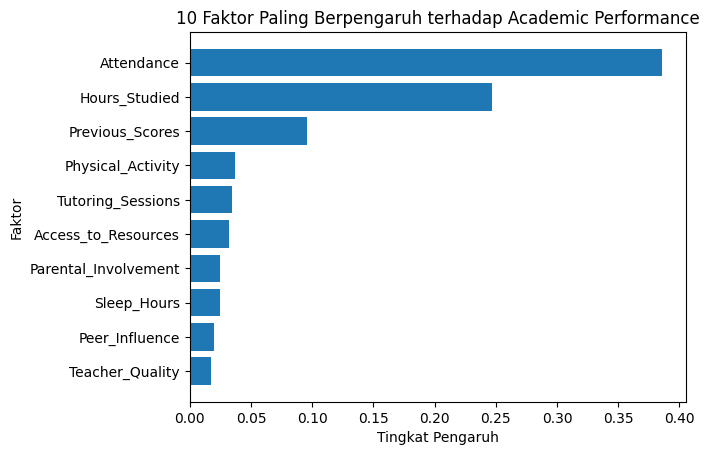

In [3]:
# ============================================
# ANALISIS FAKTOR ACADEMIC PERFORMANCE SISWA
# Model: Decision Tree Regression
# Target: Exam_Score
# ============================================

# 1. Import library
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

# 2. Load dataset
df = pd.read_csv('StudentPerformanceFactors.csv')

print("Jumlah data dan kolom:")
print(df.shape)

print("\nContoh data:")
display(df.head())

# 3. Encoding data kategorik
label_encoder = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = label_encoder.fit_transform(df[col])

# 4. Menentukan fitur (X) dan target (y)
X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

# 5. Split data latih dan uji
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 6. Membangun model Decision Tree Regression
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# 7. Prediksi nilai akademik
y_pred = model.predict(X_test)

# 8. Evaluasi model
print("\nEvaluasi Model:")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("R2 Score :", r2_score(y_test, y_pred))

# 9. Analisis faktor berpengaruh (Feature Importance)
feature_importance = pd.DataFrame({
    'Faktor': X.columns,
    'Tingkat_Pengaruh': model.feature_importances_
}).sort_values(by='Tingkat_Pengaruh', ascending=False)

print("\nFaktor-faktor yang Berpengaruh terhadap Academic Performance:")
display(feature_importance)

# 10. Visualisasi 10 faktor teratas
plt.figure()
plt.barh(
    feature_importance['Faktor'][:10],
    feature_importance['Tingkat_Pengaruh'][:10]
)
plt.xlabel('Tingkat Pengaruh')
plt.ylabel('Faktor')
plt.title('10 Faktor Paling Berpengaruh terhadap Academic Performance')
plt.gca().invert_yaxis()
plt.show()


The results of the analysis indicate that academic performance is most strongly influenced by students’ learning engagement and consistency. Variables related to attendance and study habits show the greatest impact on exam scores, highlighting the importance of regular class participation and sufficient learning time. Prior academic achievement also plays a significant role, suggesting that learning outcomes tend to be cumulative. In contrast, factors related to learning environment and external support contribute to performance but with relatively smaller influence. Overall, the findings emphasize that students’ discipline and active involvement in the learning process are key determinants of academic success.